<a href="https://colab.research.google.com/github/FatiBuuloloo/customer_segmentation_for_marketing-mini_project_004/blob/main/RFM_Customer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import re
import seaborn as sns
from sklearn.cluster import KMeans,DBSCAN,HDBSCAN,SpectralClustering

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer,QuantileTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score,calinski_harabasz_score
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans

Mounted at /content/drive


# Data Preparation

In [2]:
file_path = '/content/drive/MyDrive/Dataset/Online Retail.csv'
data = pd.read_csv(file_path)
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Removing all the negative value in **Quantity** and **UnitPrice** columns

In [5]:
data = data[(data["Quantity"]>0)&(data["UnitPrice"]>0)].reset_index(drop=True)
data["Time"] = pd.to_datetime(data.InvoiceDate).dt.strftime("%H:%M")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,08:26
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,08:26
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,08:26
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,08:26
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,08:26
...,...,...,...,...,...,...,...,...,...
530099,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,12:50
530100,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12:50
530101,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,12:50
530102,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,12:50


For this section, the focus is to fill in the missing **CustomerID** with a number (start from 1). The main idea is using **Unique Transaction ID**, where each time the timestamp changes (**InvoiceDate**) will be identified as one unique Customer

In [6]:
list_missing_index = data[data["CustomerID"].isna()].index
list_missing_index

Index([  1430,   1431,   1432,   1433,   1434,   1435,   1436,   1437,   1438,
         1439,
       ...
       529730, 529731, 529732, 529733, 529734, 529735, 529736, 529737, 529738,
       529739],
      dtype='int64', length=132220)

In [7]:
i=1
cur_date = data.loc[1430,"InvoiceDate"]
for idx in list_missing_index:
    if data.loc[idx,"InvoiceDate"]==cur_date:
        data.loc[idx,"CustomerID"] = float(i)
    elif data.loc[idx,"InvoiceDate"]!=cur_date:
        i+=1
        data.loc[idx,"CustomerID"] = float(i)

        cur_date = data.loc[idx,"InvoiceDate"]

In [8]:
data.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Time,0


In [9]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"]).dt.date
data["TotalPurchase"] = data["Quantity"]*data["UnitPrice"]

# Preprocessing Data

Checking Outlier

In [10]:
cols_numeric = ['Quantity','UnitPrice', "TotalPurchase"]
for item in cols_numeric:
  print(f"{item} Skewness: {data[item].skew()}")

Quantity Skewness: 471.7277163313442
UnitPrice Skewness: 206.08755495006463
TotalPurchase Skewness: 506.7060119422723


In [11]:
def count_outliers(df, columns):
    outlier_report = {}
    for item in columns:
        Q1 = df[item].quantile(0.25)
        Q3 = df[item].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[item] < lower_bound) | (df[item] > upper_bound)]
        outlier_report[item] = len(outliers)

    return pd.Series(outlier_report)
num_outlier = count_outliers(data, cols_numeric)
print("Total outliers for each column")
print(num_outlier)

Total outliers for each column
Quantity         56363
UnitPrice        37999
TotalPurchase    42651
dtype: int64


**Handling Outliers**

Transformation Comparison

Here are some list i use for the Transformation:
* **Quantile Transformation**
* **Log Transformation**
* **Box-Cox Transformation**
* **Yeo-Johnson Transformation**

In [12]:
qt = QuantileTransformer(output_distribution='normal')
data_qt = qt.fit_transform(data[cols_numeric])
data_qt = pd.DataFrame(data_qt,columns=cols_numeric)
num_outlier_qt = count_outliers(data_qt, cols_numeric)
print("Total outliers for each column")
print(num_outlier_qt)

Total outliers for each column
Quantity            0
UnitPrice        5250
TotalPurchase    3947
dtype: int64


In [13]:
data_log1p = np.log1p(data[cols_numeric])
data_log1p = pd.DataFrame(data_log1p,columns=cols_numeric)
num_outlier_log1p = count_outliers(data_log1p, cols_numeric)
print("Total outliers for each column")
print(num_outlier_log1p)

Total outliers for each column
Quantity         3814
UnitPrice        6567
TotalPurchase    8372
dtype: int64


In [14]:
pt_box= PowerTransformer(method='box-cox',standardize=True)
X_transformed_box = pt_box.fit_transform(data[cols_numeric])
data_BC = pd.DataFrame(X_transformed_box, columns=cols_numeric)
num_outlier_BC = count_outliers(data_BC, cols_numeric)
print("Total outliers for each column")
print(num_outlier_BC)

Total outliers for each column
Quantity            0
UnitPrice        6194
TotalPurchase    6429
dtype: int64


In [15]:
pt_yj= PowerTransformer(method='yeo-johnson',standardize=True)
X_transformed_yj = pt_yj.fit_transform(data[cols_numeric])
data_YJ= pd.DataFrame(X_transformed_yj, columns=cols_numeric)
num_outlier_YJ = count_outliers(data_YJ, cols_numeric)
print("Total outliers for each column")
print(num_outlier_YJ)

Total outliers for each column
Quantity            0
UnitPrice         896
TotalPurchase    2094
dtype: int64


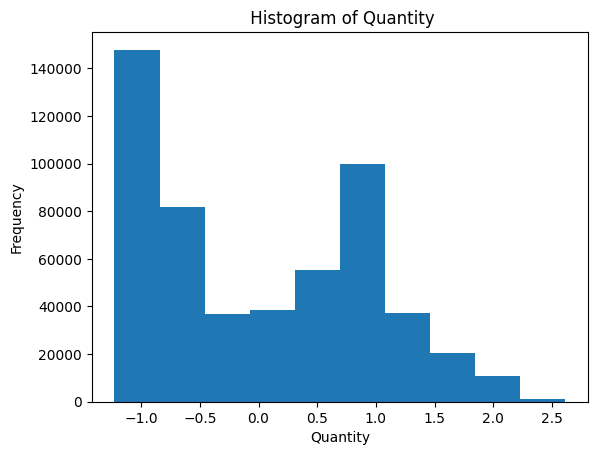

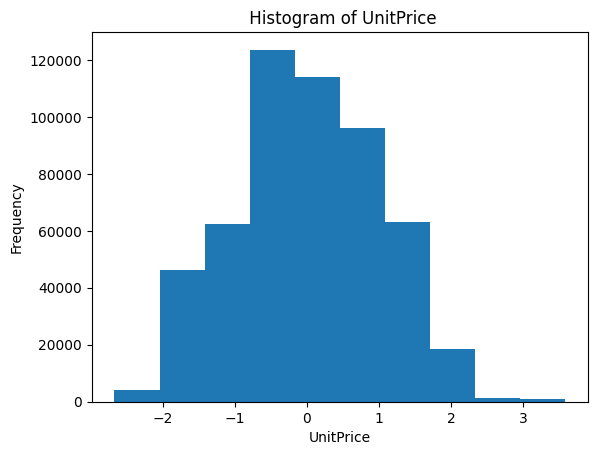

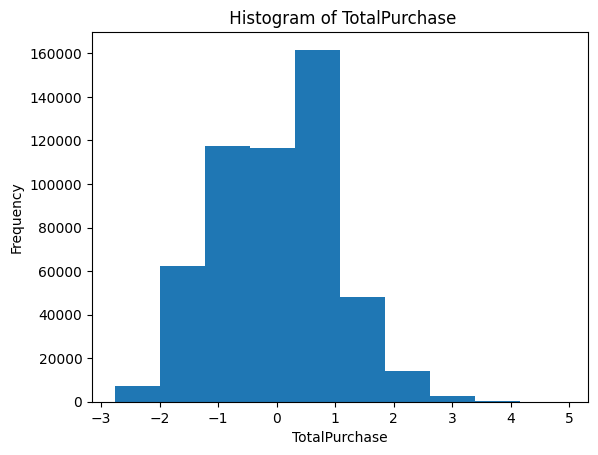

In [16]:
for item in cols_numeric:
    plt.figure()
    plt.hist(data_YJ[item])
    plt.title(f" Histogram of {item}")
    plt.xlabel(item)
    plt.ylabel("Frequency")
#plt.hist(data_YJ["Quantity"])
plt.show()

In [17]:
data[["Quantity_YJ","UnitPrice_YJ","TotalPurchase_YJ"]] = data_YJ

In [18]:
Q1 = data["UnitPrice_YJ"].quantile(0.25)
Q3 = data["UnitPrice_YJ"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
list_outlier_a = []
for idx,item in data["UnitPrice_YJ"].items():
    if item <lower_bound or item > upper_bound:
        list_outlier_a.append(idx)
    else:
        None
len(list_outlier_a)

896

In [19]:
Q1 = data["TotalPurchase_YJ"].quantile(0.25)
Q3 = data["TotalPurchase_YJ"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
list_outlier_b = []
for idx,item in data["TotalPurchase_YJ"].items():
    if item <lower_bound or item > upper_bound:
        list_outlier_b.append(idx)
    else:
        None
len(list_outlier_b)

2094

In [20]:
list_outlier = list(set(list_outlier_a) | set(list_outlier_b))

data.drop(list_outlier, inplace=True)
data.reset_index(drop=True, inplace=True)

Creating tabular data for unique customer

In [21]:
data_customer = data.groupby(["InvoiceDate","CustomerID"],as_index=False)[["TotalPurchase_YJ","TotalPurchase"]].sum().sort_values(by=["InvoiceDate","CustomerID"]).reset_index(drop=True)
data_customer["Appearance"] =1
data_customer

,InvoiceDate,CustomerID,TotalPurchase_YJ,TotalPurchase,Appearance
0,2010-12-01,1.0,-212.402148,4442.57,1
1,2010-12-01,2.0,-3.351164,2.97,1
2,2010-12-01,3.0,1.991748,99.75,1
3,2010-12-01,4.0,-1.700465,6.70,1
4,2010-12-01,5.0,-174.730501,5710.32,1
...,...,...,...,...,...
17847,2011-12-09,17389.0,4.026741,208.50,1
17848,2011-12-09,17428.0,6.592126,415.60,1
17849,2011-12-09,17490.0,17.935888,730.70,1
17850,2011-12-09,17581.0,31.259136,984.68,1


In [22]:
data_customer=data_customer.groupby(data_customer["CustomerID"]).agg({
"InvoiceDate" : "max",
"Appearance" : "sum",
"TotalPurchase" : "sum",
"TotalPurchase_YJ" : "sum"}).reset_index()

In [23]:
last_date = pd.to_datetime(data["InvoiceDate"]).max()
last_date = pd.to_datetime(last_date,format='%Y-%m-%d') + pd.Timedelta(days=1)
data_customer["Recency"]= pd.to_datetime(last_date)-pd.to_datetime(data_customer["InvoiceDate"])
data_customer

,CustomerID,InvoiceDate,Appearance,TotalPurchase,TotalPurchase_YJ,Recency
0,1.0,2010-12-01,1,4442.57,-212.402148,374 days
1,2.0,2010-12-01,1,2.97,-3.351164,374 days
2,3.0,2010-12-01,1,99.75,1.991748,374 days
3,4.0,2010-12-01,1,6.70,-1.700465,374 days
4,5.0,2010-12-01,1,5710.32,-174.730501,374 days
...,...,...,...,...,...,...
5605,18280.0,2011-03-07,1,180.60,6.582772,278 days
5606,18281.0,2011-06-12,1,80.82,0.933965,181 days
5607,18282.0,2011-12-02,2,178.05,5.037605,8 days
5608,18283.0,2011-12-06,14,2094.88,-912.181033,4 days


In [24]:
data_customer["Recency"] = data_customer["Recency"].apply(lambda x: str(x))
data_customer["Recency"] = data_customer["Recency"].apply(lambda x: int(re.findall(r"\d+", x)[0]))

In [25]:
print(f"Total Customer: {len(data_customer.CustomerID.unique())}")

Total Customer: 5610


In [26]:
data_customer.rename(columns={"Appearance":"Frequency", "TotalPurchase":"Monetary"},inplace=True)
data_customer

,CustomerID,InvoiceDate,Frequency,Monetary,TotalPurchase_YJ,Recency
0,1.0,2010-12-01,1,4442.57,-212.402148,374
1,2.0,2010-12-01,1,2.97,-3.351164,374
2,3.0,2010-12-01,1,99.75,1.991748,374
3,4.0,2010-12-01,1,6.70,-1.700465,374
4,5.0,2010-12-01,1,5710.32,-174.730501,374
...,...,...,...,...,...,...
5605,18280.0,2011-03-07,1,180.60,6.582772,278
5606,18281.0,2011-06-12,1,80.82,0.933965,181
5607,18282.0,2011-12-02,2,178.05,5.037605,8
5608,18283.0,2011-12-06,14,2094.88,-912.181033,4


In [27]:
df_X = data_customer[["Frequency", "Monetary", "Recency"]]
df_X

,Frequency,Monetary,Recency
0,1,4442.57,374
1,1,2.97,374
2,1,99.75,374
3,1,6.70,374
4,1,5710.32,374
...,...,...,...
5605,1,180.60,278
5606,1,80.82,181
5607,2,178.05,8
5608,14,2094.88,4


In [28]:
df_X.isna().sum()

,0
Frequency,0
Monetary,0
Recency,0


Scaling data

In [29]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
dfX_scaled = scaler.fit_transform(df_X)
dfX_scaled = pd.DataFrame(dfX_scaled,columns=df_X.columns)

Dimension Reduction using UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipython-input-2819126260.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.5, cmap='viridis')


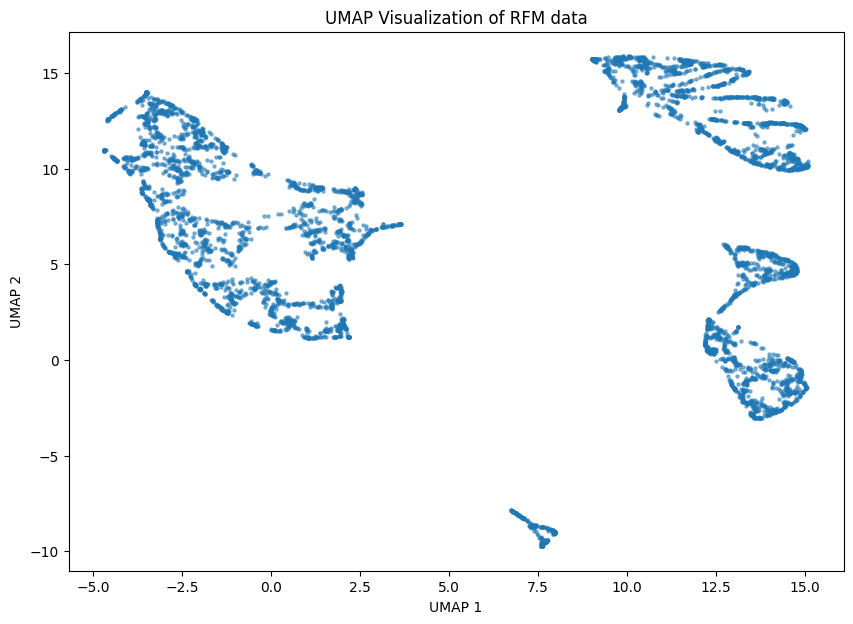

In [30]:
import umap

reducer = umap.UMAP(n_neighbors=60,
                    min_dist=0.005,
                    n_components=2,
                    random_state=42)
X_umap = reducer.fit_transform(dfX_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.5, cmap='viridis')
plt.title('UMAP Visualization of RFM data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

# Cluster Model

In [31]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, silhouette_score, davies_bouldin_score,calinski_harabasz_score
def cluster_scoring(labels):
    mask = labels!=-1
    score = calinski_harabasz_score(X_umap[mask],labels[mask])
    score1 = davies_bouldin_score(X_umap[mask],labels[mask])
    print(f"CH Score: {score}, DB Score: {score1}")
    return score1

HDBSCAN Clustering

In [32]:
hdbscan_score = {}
for i in range(20,500,5):
    hdbscan = HDBSCAN(min_cluster_size=i,min_samples=20, store_centers='medoid')
    hdbscan_labels = hdbscan.fit_predict(X_umap)
    n_clusters_h = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    print(f"i:{i} found {n_clusters_h} cluster.")
    hdbscan_score[i]=cluster_scoring(hdbscan_labels)

i:20 found 31 cluster.
CH Score: 1181.989013671875, DB Score: 0.441684915347867
i:25 found 21 cluster.
CH Score: 1840.3492431640625, DB Score: 0.4906002740473449
i:30 found 17 cluster.
CH Score: 2318.9921875, DB Score: 0.5427119732477834
i:35 found 6 cluster.
CH Score: 6937.76123046875, DB Score: 0.4812299305643797
i:40 found 6 cluster.
CH Score: 6937.76123046875, DB Score: 0.4812299305643797
i:45 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:50 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:55 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:60 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:65 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:70 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:75 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:80 found 4 cluster.
CH Score: 11619.9375, DB Score: 0.3940516280542258
i:85 found 4 cluster

In [33]:
hdbscan = HDBSCAN(min_cluster_size=45,min_samples=20, store_centers='medoid')
hdbscan_labels = hdbscan.fit_predict(X_umap)
n_clusters_h = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
cluster_scoring(hdbscan_labels)

CH Score: 11619.9375, DB Score: 0.3940516280542258


np.float64(0.3940516280542258)

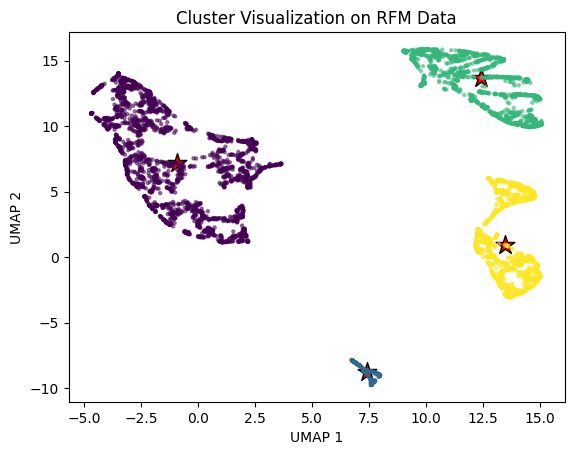

In [34]:
hdbscan_center = hdbscan.medoids_
hdbscan_center = pd.DataFrame(hdbscan_center, columns=["X","Y"])
plt.scatter(hdbscan_center["X"], hdbscan_center["Y"], s=200, c='red', marker='*', edgecolors='black', label='Centroids')
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.5, cmap='viridis',c=hdbscan_labels)
plt.title('Cluster Visualization on RFM Data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

GMM Cluster

In [35]:
from sklearn.mixture import GaussianMixture
reducer1 = umap.UMAP(n_neighbors=60,
                    min_dist=0.05,
                    n_components=2,
                    random_state=42)
X_umap1 = reducer1.fit_transform(dfX_scaled)

for i in range(2,15):
    gmm = GaussianMixture(n_components=i, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(X_umap1)
    print(f"Number cluster: {i}")
    cluster_scoring(gmm_labels)
    print()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Number cluster: 2
CH Score: 5903.08349609375, DB Score: 0.8415738651473555

Number cluster: 3
CH Score: 11767.4541015625, DB Score: 0.4943993352341849

Number cluster: 4
CH Score: 11578.208984375, DB Score: 0.39446906627240286

Number cluster: 5
CH Score: 14304.7138671875, DB Score: 0.5723889973777742

Number cluster: 6
CH Score: 15075.3662109375, DB Score: 0.5540093918292193

Number cluster: 7
CH Score: 16472.806640625, DB Score: 0.5808298870445218

Number cluster: 8
CH Score: 16345.7314453125, DB Score: 0.7321191086170512

Number cluster: 9
CH Score: 24279.447265625, DB Score: 0.5628928254676301

Number cluster: 10
CH Score: 17342.560546875, DB Score: 0.892088928790448

Number cluster: 11
CH Score: 21577.5390625, DB Score: 0.6825728166244939

Number cluster: 12
CH Score: 21576.783203125, DB Score: 0.7165025075100068

Number cluster: 13
CH Score: 24366.533203125, DB Score: 0.7279131599742067

Number cluster: 14
CH Score: 26543.9609375, DB Score: 0.7193898067401029



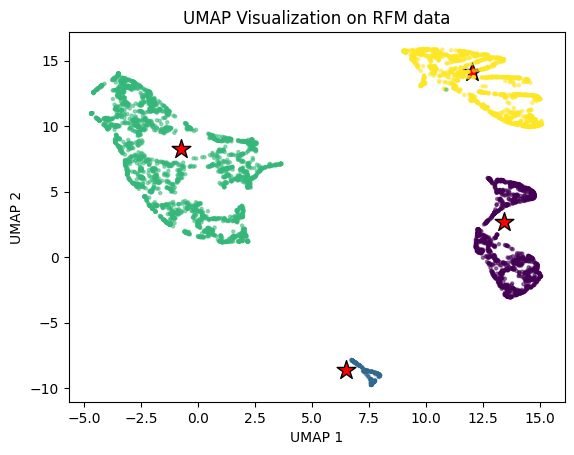

In [36]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_umap1)
gmm_center = gmm.means_
gmm_center = pd.DataFrame(gmm_center, columns=["X","Y"])
plt.scatter(gmm_center["X"], gmm_center["Y"], s=200, c='red', marker='*', edgecolors='black', label='Centroids')
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.5, cmap='viridis',c=gmm_labels)
plt.title('UMAP Visualization on RFM data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

Because HDBSCAN has the best Davies Bouldin Score, so i choose the HDBSCAN cluster labels

In [37]:
import plotly.graph_objects as go

data_new = df_X.copy()
data_new["cluster_hdbscan"] = hdbscan_labels
features = df_X.columns.tolist()

df_clean = data_new[data_new['cluster_hdbscan'] != -1]
centroids_hdbscan = df_clean.groupby('cluster_hdbscan')[features].mean().reset_index()
scaler_hdbscan = MinMaxScaler()
centroids_scaled_hdbscan = scaler_hdbscan.fit_transform(centroids_hdbscan[features])
centroids_scaled_df_hdbscan = pd.DataFrame(centroids_scaled_hdbscan, columns=features)
centroids_scaled_df_hdbscan['cluster'] = centroids_hdbscan['cluster_hdbscan']
def create_radar_chart(df_centroids, features):
    fig = go.Figure()
    for i in range(len(df_centroids)):
        values = df_centroids.iloc[i][features].tolist()
        values += [values[0]]
        feature_list = features + [features[0]]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=feature_list,
            fill='toself',
            name=f'Cluster {int(df_centroids.iloc[i]["cluster"])}',
            hovertemplate='%{theta}: %{r:.2f}<extra></extra>'))
    fig.update_layout(
        width=500,
        height=350,
        title=dict(
            text="Characteristic Profile on Each Cluster",
            font=dict(size=24),
            x=0.5,
            xanchor='center'),
        margin=dict(l=100, r=100, t=100, b=100),
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickfont=dict(size=12)),
            angularaxis=dict(
                tickfont=dict(size=14))),
        legend=dict(
            font=dict(size=14),
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.1),
        showlegend=True,
        template="plotly_white")
    fig.show()
create_radar_chart(centroids_scaled_df_hdbscan, features)

In [38]:
data_new.groupby("cluster_hdbscan")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
cluster_hdbscan,,,
0,160.331543,1.017652,611.304939
1,364.083721,1.000000,159.872605
2,32.476381,7.935462,4045.973333
3,82.882582,2.377916,705.107661


In [39]:
data_new[data_new["cluster_hdbscan"]==0].describe()

,Frequency,Monetary,Recency,cluster_hdbscan
count,2606.000000,2606.000000,2606.000000,2606.0
mean,1.017652,611.304939,160.331543,0.0
std,0.150735,852.597683,105.285273,0.0
min,1.000000,0.350000,1.000000,0.0
25%,1.000000,112.600000,61.000000,0.0
50%,1.000000,298.440000,157.000000,0.0
75%,1.000000,749.915000,255.000000,0.0
max,4.000000,6839.930000,374.000000,0.0


In [40]:
data_new[data_new["cluster_hdbscan"]==0].sort_values(by=["Frequency","Recency"],ascending=False)

,Frequency,Monetary,Recency,cluster_hdbscan
3833,4,3734.97,307,0
4850,4,3638.41,265,0
1628,3,2593.14,236,0
5293,2,5391.21,373,0
3484,2,1661.06,367,0
...,...,...,...,...
2110,1,196.89,2,0
2929,1,227.39,2,0
3619,1,343.50,2,0
1296,1,2778.96,1,0


In [42]:
data_new[data_new["cluster_hdbscan"]==1].sort_values(by=["Recency","Monetary"],ascending=False)

,Frequency,Monetary,Recency,cluster_hdbscan
5456,1,489.60,374,1
3360,1,487.75,374,1
3915,1,369.50,374,1
4169,1,357.95,374,1
3042,1,313.49,374,1
...,...,...,...,...
137,1,26.15,352,1
141,1,15.25,352,1
140,1,12.45,352,1
145,1,7.10,352,1


In [43]:
data_new[data_new["cluster_hdbscan"]==2].sort_values(by=["Frequency","Monetary"],ascending=False)

,Frequency,Monetary,Recency,cluster_hdbscan
3172,131,134762.12,2,2
1623,113,31564.23,1,2
5288,112,40642.07,2,2
3468,90,60359.90,1,2
2954,89,12071.65,2,2
...,...,...,...,...
1267,1,3735.99,6,2
1291,1,3578.45,2,2
1179,1,3530.58,29,2
1221,1,3449.94,18,2


In [44]:
data_new[data_new["cluster_hdbscan"]==3].sort_values(by=["Frequency","Recency","Monetary"],ascending=False)

,Frequency,Monetary,Recency,cluster_hdbscan
3312,6,319.50,312,3
4492,6,781.02,303,3
4737,4,538.37,314,3
5343,4,311.01,311,3
2487,4,664.54,309,3
...,...,...,...,...
4199,2,326.75,2,3
2891,2,270.60,2,3
2088,2,252.49,2,3
4998,2,216.30,2,3


In [45]:
data_new.groupby("cluster_hdbscan").agg({
"Recency":"max",
"Frequency":"max",
"Monetary":"max"
})

,Recency,Frequency,Monetary
cluster_hdbscan,,,
0,374,4,6839.93
1,374,1,754.87
2,368,131,220896.04
3,361,6,2338.60


In [46]:
def convert_label(item):
    if item==2:
        return "Loyal"
    elif item == 1:
        return "Loss Customer"
    elif item == 3:
        return "Promising Customer"
    else:
        return "Potential Lapsed"


data_customer.drop("TotalPurchase_YJ",axis=1)
data_customer["Category"] = hdbscan_labels
data_customer["Category"] = data_customer["Category"].apply(convert_label)
data_customer

,CustomerID,InvoiceDate,Frequency,Monetary,TotalPurchase_YJ,Recency,Category
0,1.0,2010-12-01,1,4442.57,-212.402148,374,Potential Lapsed
1,2.0,2010-12-01,1,2.97,-3.351164,374,Loss Customer
2,3.0,2010-12-01,1,99.75,1.991748,374,Loss Customer
3,4.0,2010-12-01,1,6.70,-1.700465,374,Loss Customer
4,5.0,2010-12-01,1,5710.32,-174.730501,374,Potential Lapsed
...,...,...,...,...,...,...,...
5605,18280.0,2011-03-07,1,180.60,6.582772,278,Potential Lapsed
5606,18281.0,2011-06-12,1,80.82,0.933965,181,Potential Lapsed
5607,18282.0,2011-12-02,2,178.05,5.037605,8,Promising Customer
5608,18283.0,2011-12-06,14,2094.88,-912.181033,4,Loyal


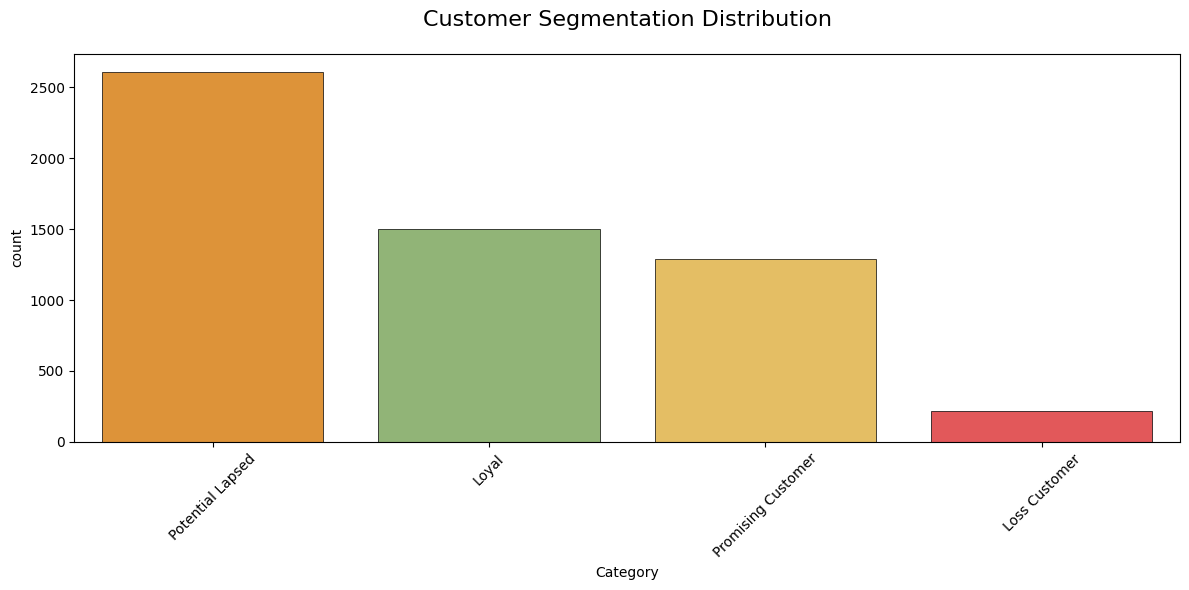

In [47]:
data_category = data_customer["Category"].value_counts().reset_index()
my_colors = {
    'Loyal': '#90BE6D',
    'Loss Customer': '#F94144',
    'Promising Customer': '#F9C74F',
    'Potential Lapsed': '#F8961E'
    }

plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_category,
    x='Category',
    y='count',
    hue='Category',
    palette=my_colors,
    legend=False,
    edgecolor='black',
    linewidth=0.5)
plt.title("Customer Segmentation Distribution", fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()